# Conditional WGAN-GP — Hyperparameter Search with Optuna
This notebook extends the `conditional_wgan_gp` notebook with an Optuna study that searches over
`lr_G`, `lr_D`, `lambda_fm_1`, `lambda_fm_2`, and `lambda_entropy`.
After the search we retrain a final model with the best hyperparameters and inspect the results.

In [18]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import rbf_kernel
import optuna
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
)
from synthetic_generation.gan.models import Generator, Discriminator, OutputHead
from synthetic_generation.gan.activations import ClampedIdentity
from synthetic_generation.gan.training import train_wgan_gp

optuna.logging.set_verbosity(optuna.logging.WARNING)

#### Creating Data
We use the same ring-of-8-clusters dataset as the base notebook. The conditional vector
concatenates scaled cluster centers with one-hot encoded labels.

In [2]:
def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Parameters
    ----------
    n_samples : int
        number of samples
    centers : int
        number of disk clusters
    radius : float
        radius of ring containing centers of the clusters
    std : float
        standard deviation for distance from center of disk for a point
    seed : int
        random seed to use
    Returns
    -------
    tuple
        array of sample points, array of cluster centers for each point,
        array of labels for each cluster
    """
    rng = np.random.default_rng(seed)
    angles = np.linspace(0, 2 * np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles),
    ], axis=1)

    samples, sample_labels, sample_centers = [], [], []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        samples.append(rng.normal(loc=means[k], scale=std, size=2))

    return (
        np.array(samples, dtype=np.float32),
        np.array(sample_labels),
        np.array(sample_centers, dtype=np.float32),
    )

In [3]:
X, c_label, c_center = make_gaussian_mixture()

# one-hot encode labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

# scale X and centers to [-1, 1]
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = 2 * (X - X_min) / (X_max - X_min) - 1
c_center_scaled = 2 * (c_center - X_min) / (X_max - X_min) - 1

# combined conditional: scaled centers + one-hot labels
c = torch.cat([torch.tensor(c_center_scaled), one_hot], dim=1)
X_tensor = torch.tensor(X_scaled)

CONDITIONAL_DIM = c.shape[1]   # 2 + 8 = 10
print(f"X_tensor: {X_tensor.shape}, c: {c.shape}")

X_tensor: torch.Size([50000, 2]), c: torch.Size([50000, 10])


#### Evaluation Metric
We need a differentiable-free quality score to drive the Optuna objective.
After training we generate one sample per real data-point (using the same conditionals),
then measure the MMD compared to a held out data set.

In [4]:
# combine the data and conditionals into a Dataset
dataset = TensorDataset(X_tensor.float(),c)
# Define the split ratio
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoader for each dataset
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True)
# now we want to combine the test data into just one X_test, c_test
test_data = []
test_conditional = []
for batch in test_loader:
    test_data.append(batch[0])
    test_conditional.append(batch[1])

X_test = torch.cat(test_data)
c_test = torch.cat(test_conditional)

In [5]:
def mmd(X, Y, gamma=1.0):
    """
    computes MMD(X, Y)
    """
    XX = rbf_kernel(X, X, gamma).mean()
    YY = rbf_kernel(Y, Y, gamma).mean()
    XY = rbf_kernel(X, Y, gamma).mean()
    return XX + YY - 2*XY

In [6]:
def compute_per_cluster_mmd(
    G: Generator,
    c_val: torch.Tensor,
    X_val_np: np.ndarray,
    gamma: float = 1.0
):
    G.eval()
    with torch.no_grad():
        device = next(G.parameters()).device
        x_fake = G.generate_samples(num_samples=len(c_val), c=c_val.to(device)).cpu().numpy()
    G.train()
    
    # extract cluster labels from one-hot part of conditional
    labels = c_val[:, 2:].argmax(dim=1).cpu().numpy()  # 2: skips the 2 center coords
    
    mmds = []
    for label in range(8):  # 8 clusters
        mask = labels == label
        mmds.append(mmd(x_fake[mask], X_val_np[mask], gamma=gamma))
    
    return np.mean(mmds)

In [13]:
# at the top, before the objective function
X_test_np = X_test.numpy()  # keep as numpy for rbf_kernel

#### Optuna Objective
Each trial:
1. Samples hyperparameters from the search space
2. Builds fresh G and D
3. Trains for `SEARCH_EPOCHS` epochs (shorter than the full run)
4. Returns MMD mean per cluster — Optuna minimises this

In [7]:
def make_callback(trial):
    # create the callback for pruning
    def callback(state):
        trial.report(state["g_loss"], state["epoch"])
        return trial.should_prune()
    return callback

In [8]:
SEARCH_EPOCHS = 100   # quick enough for many trials; bump up if you have a GPU
N_TRIALS      = 50


def objective(trial: optuna.Trial) -> float:
    # --- hyperparameter search space ---
    lr_G          = trial.suggest_float("lr_G",          1e-5, 1e-3, log=True)
    lr_D          = trial.suggest_float("lr_D",          1e-5, 1e-3, log=True)
    lambda_gp     = trial.suggest_float("lambda_gp", 0.1, 50.0, log=True)
    n_critic      = trial.suggest_int("n_critic", 1, 8)
    lambda_fm_1   = trial.suggest_float("lambda_fm_1", 0.0, 0.1)
    lambda_fm_2   = trial.suggest_float("lambda_fm_2", 0.0, 0.1)
    lambda_entropy = trial.suggest_float("lambda_entropy", 0.0, 0.01)

    torch.manual_seed(trial.number)  # reproducible per trial

    heads = [OutputHead(dim=2, activation=nn.Tanh, decode=nn.Tanh, name="scaled_output")]
    G = Generator(
        noise_dim=2,
        num_hidden_layers=2,
        output_heads=heads,
        hidden_dims=(128, 128),
        conditional_dim=CONDITIONAL_DIM,
    )
    D = Discriminator(
        feature_dim=2,
        num_hidden_layers=2,
        hidden_dims=(128, 128),
        conditional_dim=CONDITIONAL_DIM,
    )

    train_wgan_gp(
        G=G, D=D,
        X=train_loader,
        lr_G=lr_G, lr_D=lr_D,
        lambda_fm_1=lambda_fm_1,
        lambda_fm_2=lambda_fm_2,
        lambda_gp=lambda_gp,
        n_critic=n_critic,
        lambda_entropy=lambda_entropy,
        epochs=SEARCH_EPOCHS,
        epoch_callback=make_callback(trial),
        callback_every=5,
    )

    return compute_per_cluster_mmd(G, c_test, X_test_np)

#### Run the Study

In [34]:
sampler = optuna.samplers.TPESampler(seed=0)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

...

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

#### Best Parameters

In [35]:
best = study.best_trial
print(f"Best trial: #{best.number}  MMD = {best.value:.6f}")
print("Best hyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v:.6g}")

Best trial: #33  MMD = 0.000285
Best hyperparameters:
  lr_G: 1.61144e-05
  lr_D: 0.000999632
  lambda_gp: 0.176651
  n_critic: 7
  lambda_fm_1: 0.0598192
  lambda_fm_2: 0.0504165
  lambda_entropy: 0.00529136


#### Optuna Visualizations

C:\Users\ronsp\AppData\Local\Temp\ipykernel_19376\984341679.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


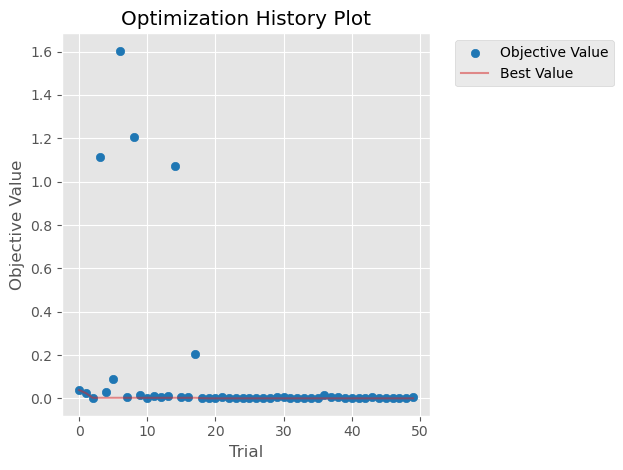

C:\Users\ronsp\AppData\Local\Temp\ipykernel_19376\984341679.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


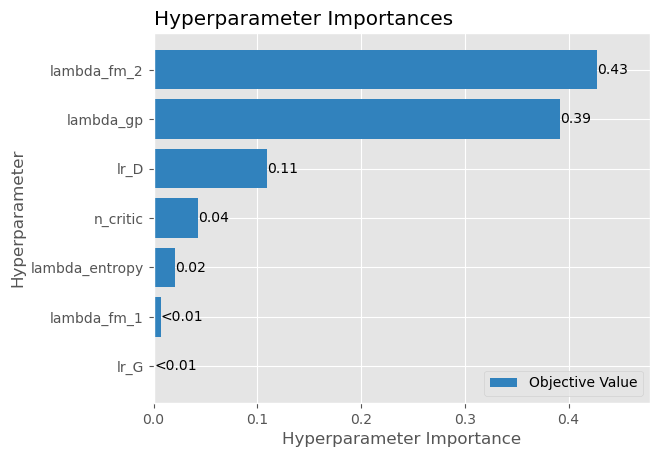

In [36]:


plot_optimization_history(study)
plt.show()

plot_param_importances(study)
plt.show()

#plot_parallel_coordinate(study)
#plt.show()

#### Final Training with Best Hyperparameters
We now train a full model for 200 epochs using the hyperparameters selected by the study.

In [37]:
torch.manual_seed(42)

bp = best.params

heads_final = [OutputHead(dim=2, activation=nn.Tanh, decode=nn.Tanh, name="scaled_output")]
G_final = Generator(
    noise_dim=2,
    num_hidden_layers=2,
    output_heads=heads_final,
    hidden_dims=(128, 128),
    conditional_dim=CONDITIONAL_DIM,
)
D_final = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128, 128),
    conditional_dim=CONDITIONAL_DIM,
)

G_losses, D_losses = train_wgan_gp(
    G=G_final, D=D_final,
    X=X_tensor, c=c,
    lr_G=bp["lr_G"],
    lr_D=bp["lr_D"],
    lambda_fm_1=bp["lambda_fm_1"],
    lambda_fm_2=bp["lambda_fm_2"],
    lambda_entropy=bp["lambda_entropy"],
    n_critic=bp["n_critic"],
    lambda_gp=bp["lambda_gp"],
    epochs=200,
    return_history=True,
)

WGAN-GP training:   0%|          | 0/200 [00:00<?, ?it/s]

#### Training Loss Curves

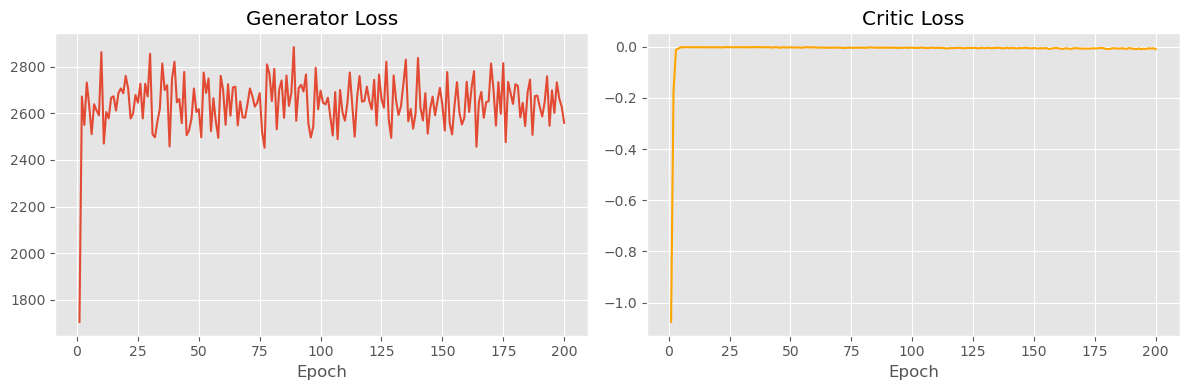

In [38]:
g_epochs, g_vals = zip(*G_losses)
d_epochs, d_vals = zip(*D_losses)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(g_epochs, g_vals)
axs[0].set_title("Generator Loss")
axs[0].set_xlabel("Epoch")
axs[1].plot(d_epochs, d_vals, color="orange")
axs[1].set_title("Critic Loss")
axs[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

#### Visualisation — Real vs Generated

In [30]:
@torch.no_grad()
def plot_samples(
    G: Generator,
    X_real: np.ndarray,
    c: torch.Tensor,
    c_label: np.ndarray,
    n: int = 2000,
    title: str | None = None,
):
    """
    Plot sample points from the real data and fake data from the generator.

    Parameters
    ----------
    G : Generator
    X_real : np.ndarray  — unscaled real data
    c : torch.Tensor  — conditional (used for generation)
    c_label : np.ndarray  — integer labels (used for coloring)
    n : int  — number of points to plot
    title : str | None
    """
    device = next(G.parameters()).device
    c_in = c[:n].to(device)
    x_fake = G.generate_samples(num_samples=n, c=c_in).cpu().numpy()
    x_fake_unscaled = (x_fake + 1) / 2 * (X_max - X_min) + X_min

    fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    axs[0].scatter(X_real[:n, 0], X_real[:n, 1], c=c_label[:n], alpha=0.3, cmap="tab10")
    axs[0].set_title("Real")
    axs[1].scatter(x_fake_unscaled[:, 0], x_fake_unscaled[:, 1], c=c_label[:n], alpha=0.3, cmap="tab10")
    axs[1].set_title("Generated")
    if title is not None:
        fig.suptitle(title)
    plt.show()

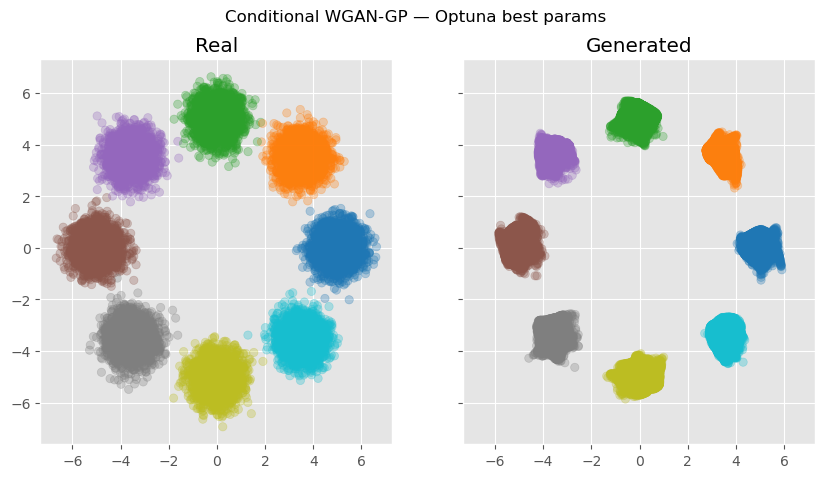

In [40]:
plot_samples(G_final, X, c, c_label, n=20000, title="Conditional WGAN-GP — Optuna best params")

#### Final Evaluation Score

In [41]:
final_mmd = compute_per_cluster_mmd(G_final, c_test, X_val_np=X_test_np)
print(f"Final cluster MMD (full training): {final_mmd:.6f}")
print(f"Search cluster MMD (best trial):   {best.value:.6f}")

Final cluster MMD (full training): 0.000193
Search cluster MMD (best trial):   0.000285


We saw that by using hyperparameter training with an objective of mean intracluster MMD, we got significant improvement from what we had before. While the generated data is still not at the level of other methods, we get somewhat disk-like clusters rather than long squiggles. 

One thing we saw was that the pruning was fairly aggressive. Also, using $\tanh$ for training at the output could have some gradient issues. So we will repeat the process making two changes.
1. Use a `ClampedIdentity` for inference but leave the training with just linear output
2. Change the `callback_every` to 25 epochs to make the pruning less aggressive

In [ ]:

def objective_2(trial: optuna.Trial) -> float:
    # --- hyperparameter search space ---
    lr_G          = trial.suggest_float("lr_G",          1e-5, 1e-3, log=True)
    lr_D          = trial.suggest_float("lr_D",          1e-5, 1e-3, log=True)
    lambda_gp     = trial.suggest_float("lambda_gp", 0.1, 50.0, log=True)
    n_critic      = trial.suggest_int("n_critic", 1, 8)
    lambda_fm_1   = trial.suggest_float("lambda_fm_1", 0.0, 0.1)
    lambda_fm_2   = trial.suggest_float("lambda_fm_2", 0.0, 0.1)
    lambda_entropy = trial.suggest_float("lambda_entropy", 0.0, 0.01)

    torch.manual_seed(trial.number)  # reproducible per trial

    heads = [OutputHead(dim=2, decode=ClampedIdentity(min_value=-1, max_value=1)ClampedIdentity(min_value=-1, max_value=1), name="scaled_output")]
    G = Generator(
        noise_dim=2,
        num_hidden_layers=2,
        output_heads=heads,
        hidden_dims=(128, 128),
        conditional_dim=CONDITIONAL_DIM,
    )
    D = Discriminator(
        feature_dim=2,
        num_hidden_layers=2,
        hidden_dims=(128, 128),
        conditional_dim=CONDITIONAL_DIM,
    )

    train_wgan_gp(
        G=G, D=D,
        X=train_loader,
        lr_G=lr_G, lr_D=lr_D,
        lambda_fm_1=lambda_fm_1,
        lambda_fm_2=lambda_fm_2,
        lambda_gp=lambda_gp,
        n_critic=n_critic,
        lambda_entropy=lambda_entropy,
        epochs=SEARCH_EPOCHS,
        epoch_callback=make_callback(trial),
        callback_every=25,
    )

    return compute_per_cluster_mmd(G, c_test, X_test_np)

In [21]:
storage = f"sqlite:///{os.path.join(os.getcwd(), 'optuna_study.db')}"

In [22]:
sampler_2 = optuna.samplers.TPESampler(seed=0)
study_2 = optuna.create_study(
    direction="minimize",
    sampler=sampler_2,
    storage=storage,
    study_name="wgan_gp_per_cluster_clamped_identity",
    load_if_exists=True
)
study_2.optimize(objective_2, n_trials=N_TRIALS, show_progress_bar=True)

  0%|          | 0/50 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

...

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

WGAN-GP training:   0%|          | 0/100 [00:00<?, ?it/s]

In [23]:
best_2 = study_2.best_trial
print(f"Best trial: #{best_2.number}  MMD = {best_2.value:.6f}")
print("Best hyperparameters:")
for k, v in best_2.params.items():
    print(f"  {k}: {v:.6g}")

Best trial: #21  MMD = 0.000250
Best hyperparameters:
  lr_G: 0.000152295
  lr_D: 1.80932e-05
  lambda_gp: 2.64918
  n_critic: 6
  lambda_fm_1: 0.0395238
  lambda_fm_2: 0.099281
  lambda_entropy: 0.00827709


C:\Users\ronsp\AppData\Local\Temp\ipykernel_28408\1208227106.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_2)


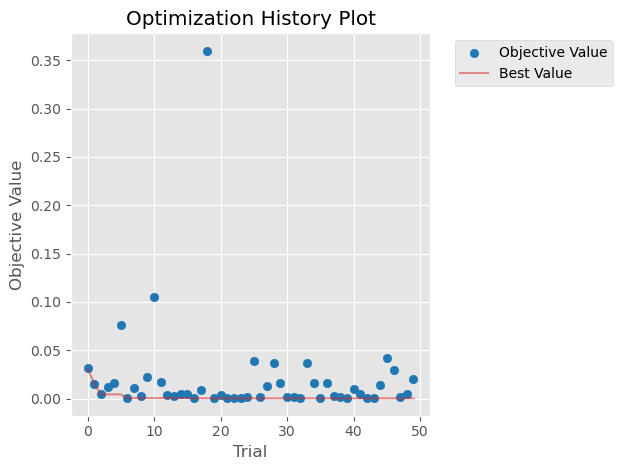

C:\Users\ronsp\AppData\Local\Temp\ipykernel_28408\1208227106.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_2)


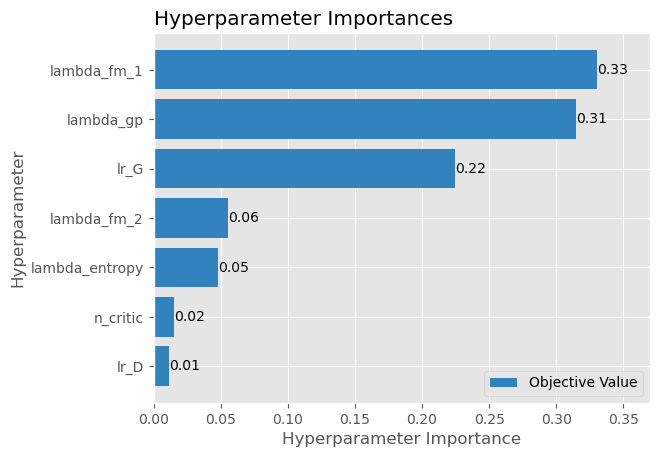

In [24]:
plot_optimization_history(study_2)
plt.show()

plot_param_importances(study_2)
plt.show()

In [27]:
torch.manual_seed(42)

bp = best_2.params

heads_final = [OutputHead(dim=2, decode=ClampedIdentity(min_value=-1, max_value=1), name="scaled_output")]
G_final = Generator(
    noise_dim=2,
    num_hidden_layers=2,
    output_heads=heads_final,
    hidden_dims=(128, 128),
    conditional_dim=CONDITIONAL_DIM,
)
D_final = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128, 128),
    conditional_dim=CONDITIONAL_DIM,
)

G_losses, D_losses = train_wgan_gp(
    G=G_final, D=D_final,
    X=X_tensor, c=c,
    lr_G=bp["lr_G"],
    lr_D=bp["lr_D"],
    lambda_fm_1=bp["lambda_fm_1"],
    lambda_fm_2=bp["lambda_fm_2"],
    lambda_entropy=bp["lambda_entropy"],
    n_critic=bp["n_critic"],
    lambda_gp=bp["lambda_gp"],
    epochs=200,
    return_history=True,
)

WGAN-GP training:   0%|          | 0/200 [00:00<?, ?it/s]

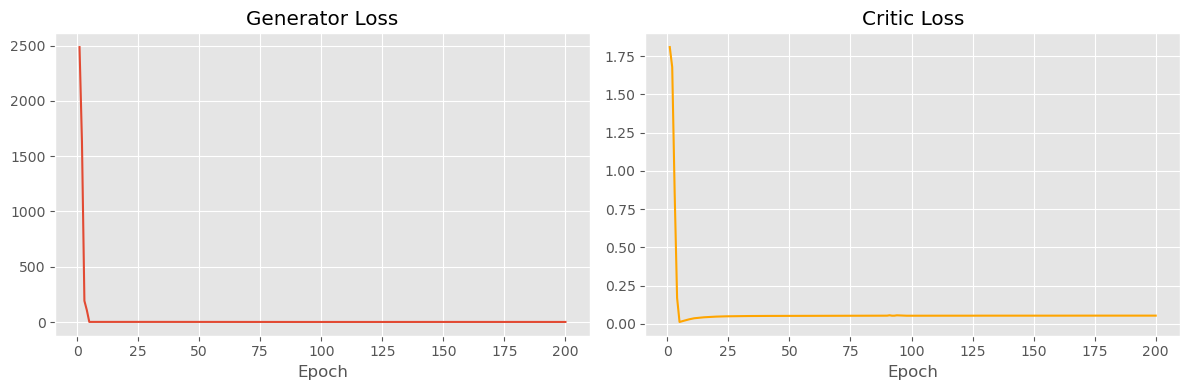

In [28]:
g_epochs, g_vals = zip(*G_losses)
d_epochs, d_vals = zip(*D_losses)

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(g_epochs, g_vals)
axs[0].set_title("Generator Loss")
axs[0].set_xlabel("Epoch")
axs[1].plot(d_epochs, d_vals, color="orange")
axs[1].set_title("Critic Loss")
axs[1].set_xlabel("Epoch")
plt.tight_layout()
plt.show()

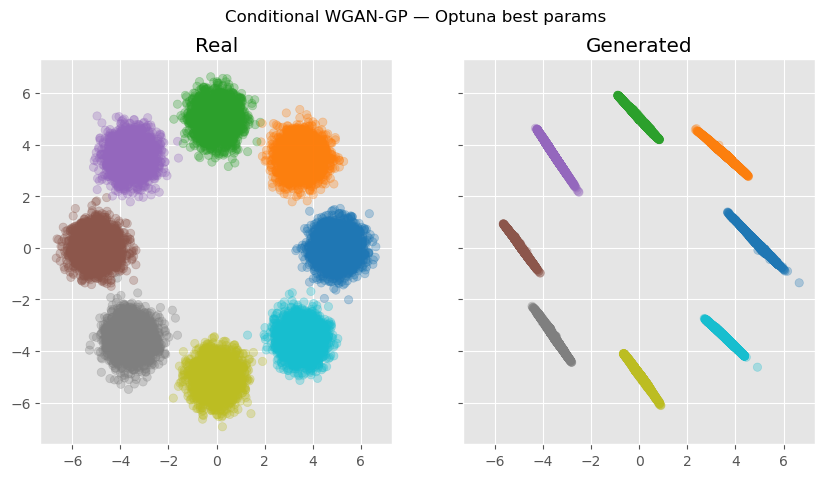

In [31]:
plot_samples(G_final, X, c, c_label, n=20000, title="Conditional WGAN-GP — Optuna best params")

In [32]:
final_mmd = compute_per_cluster_mmd(G_final, c_test, X_val_np=X_test_np)
print(f"Final cluster MMD (full training): {final_mmd:.6f}")
print(f"Search cluster MMD (best trial):   {best_2.value:.6f}")

Final cluster MMD (full training): 0.000482
Search cluster MMD (best trial):   0.000250


### Conclusions
I first wanted to look at this because the inital results from conditional WGAN-GP were pretty bad, and I wondered if we could improve upon them. With some hyperparameter tuning using the same setup ($\tanh$ activation/inference at output) we got results that were an improvement on what we saw without the hyperparameters but did not outperform other methods.

I took a look at the idea of taking away the $\tanh$ and letting the output be unconstrained during training and just clamping to $\left[-1,1\right]$ at inference, and the hyperparameter tuning had an outcome that was better than what we saw from the tuning on the $\tanh$ version. However, when we let it go for 200 epochs on the full data, the performance degraded both visually (back to strips instead of disks) and worse mean intra-cluster MMD. The worse behavior would almost certainly come from 
1. sensitivity to initial weights and other random processes for training
2. degradation over a longer training period
or 
3. Some combination of both

In the end, I saw the WGAN-GP could be improved from the bad strips we saw originally on this ring of clusters structure, but not to the level we saw with other methods, and requires careful tuning and/or some luck with randomness to get it to improve over the really bad results. This suggests that at least for this geometry, WGAN-GP isn't a great way to generate data, despite the theoretical advantages of using the Wasserstein distance, especially with how easily it can revert to bad output.